# 03 - Model Training Results

Loads `results/metrics/all_results.csv` (written by `scripts/train_all.py`) and compares all 7 model families across all 6 vegetables on the held-out final year. Run `python scripts/train_all.py` first if this file doesn't exist yet.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.read_csv('../results/metrics/all_results.csv')
results

,vegetable,model,mae,rmse,mape,r2,cv_mae,cv_rmse,cv_mape,cv_r2
0,carrot,sarimax,252.831233,314.095841,42.184232,-1.817532,184.808882,220.790302,74.311607,-15.899669
1,brinjal,sarimax,89.074017,115.207707,18.422888,-0.134426,70.010225,86.549945,26.767980,-0.488160
2,pumpkin,sarimax,97.627866,110.771463,52.105444,-3.625397,76.066372,90.112725,49.521031,-4.536323
3,cabbage,sarimax,79.811229,97.374812,20.232733,-0.352760,83.915505,106.487385,42.176580,-2.064231
4,snake_gourd,sarimax,82.088192,95.434241,21.910134,-0.052219,48.431591,58.574612,19.669006,-0.489383
5,leeks,sarimax,64.515643,75.147432,20.830072,-0.094072,154.087631,178.355054,75.483694,-7.331699
6,carrot,random_forest,95.598639,133.053468,16.818981,0.494412,40.939336,77.396658,10.998125,0.582245
7,brinjal,random_forest,58.627007,82.284722,12.063352,0.421303,41.352272,59.859668,13.127610,0.294437
8,pumpkin,random_forest,15.483967,22.799790,7.301368,0.804046,17.001971,25.674433,9.014159,0.693874
9,cabbage,random_forest,30.085797,42.210004,7.660130,0.745810,38.149097,55.245260,12.898705,0.477699


## RMSE comparison (holdout year), lower is better

In [2]:
comparison = results.pivot(index='vegetable', columns='model', values='rmse')
comparison.round(1)

model,catboost,hybrid_catboost_sarimax,hybrid_xgboost_sarimax,lstm,random_forest,sarimax,xgboost
vegetable,,,,,,,
brinjal,96.9,133.7,139.5,137.0,82.3,115.2,106.6
cabbage,62.2,109.5,109.9,99.0,42.2,97.4,50.6
carrot,114.4,296.7,268.6,163.7,133.1,314.1,184.2
leeks,46.0,74.8,74.2,66.2,47.7,75.1,49.7
pumpkin,26.8,110.6,111.3,65.6,22.8,110.8,23.3
snake_gourd,71.5,105.8,108.2,87.1,62.5,95.4,72.7


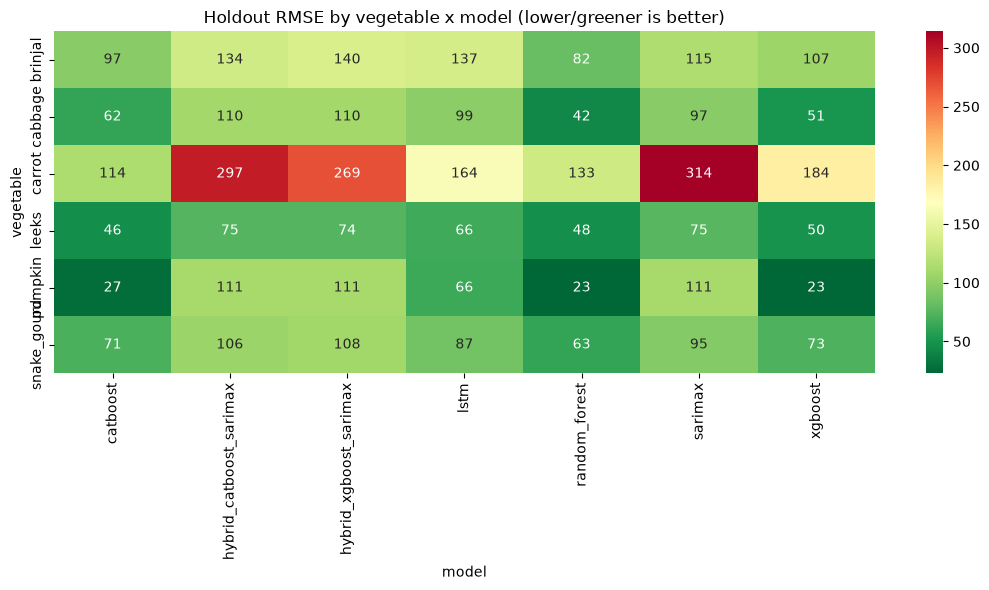

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(comparison, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Holdout RMSE by vegetable x model (lower/greener is better)')
plt.tight_layout(); plt.show()

## Best model per vegetable

In [4]:
best = comparison.idxmin(axis=1)
best.to_frame('best_model_by_rmse')

,best_model_by_rmse
vegetable,
brinjal,random_forest
cabbage,random_forest
carrot,catboost
leeks,catboost
pumpkin,random_forest
snake_gourd,random_forest


## R² comparison

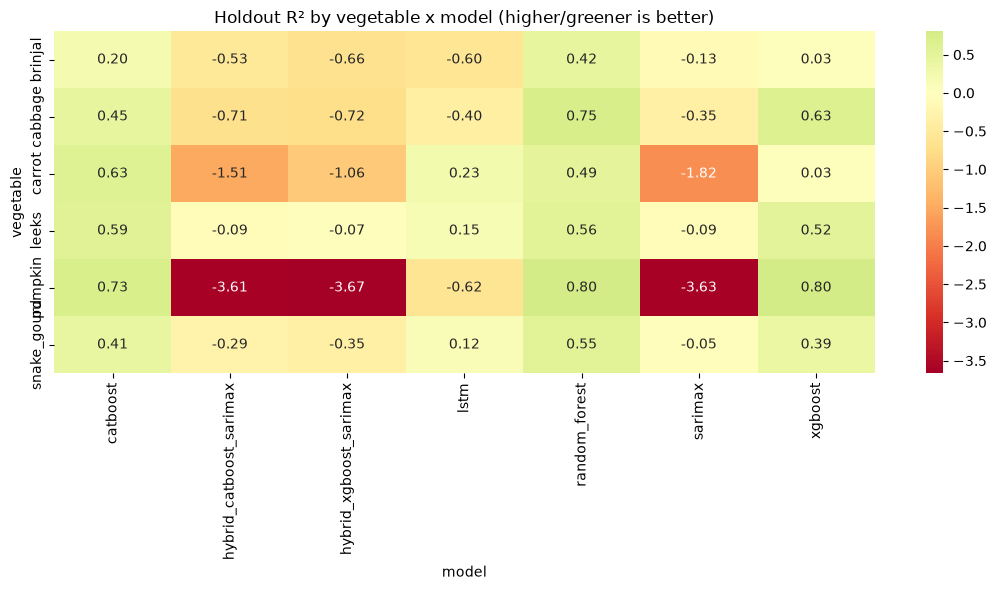

In [5]:
r2_table = results.pivot(index='vegetable', columns='model', values='r2')
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(r2_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Holdout R\u00b2 by vegetable x model (higher/greener is better)')
plt.tight_layout(); plt.show()

## Overall model ranking (mean rank across vegetables, by RMSE)

In [6]:
ranks = comparison.rank(axis=1)
ranks.mean().sort_values().to_frame('mean_rank_across_vegetables')

,mean_rank_across_vegetables
model,
random_forest,1.333333
catboost,2.000000
xgboost,2.833333
lstm,4.333333
sarimax,5.500000
hybrid_catboost_sarimax,5.666667
hybrid_xgboost_sarimax,6.333333
